In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("Setup Complete! CPU mode enabled.")

Setup Complete! CPU mode enabled.


In [2]:
# Folder path
train_dir = 'train'
test_dir = 'test'

# Data Preprocessing (Normalization & Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Loading images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

Found 10901 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


In [3]:
model = Sequential([
    # Input Layer & First Conv Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    
    # Second Conv Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Third Conv Layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Flatten & Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax') # 6 ta category thakle 6 hobe
])

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

c:\Users\Sneha Deyashi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Training start
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
) 

# Model save kora
model.save('vegetable_model.h5')
print("Model trained and saved successfully as vegetable_model.h5")

Epoch 1/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 390s 567ms/step - accuracy: 0.6372 - loss: 0.9923 - val_accuracy: 0.8462 - val_loss: 0.4490
Epoch 2/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 447s 655ms/step - accuracy: 0.8038 - loss: 0.5735 - val_accuracy: 0.8810 - val_loss: 0.3174
Epoch 3/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 455s 667ms/step - accuracy: 0.8256 - loss: 0.4857 - val_accuracy: 0.9133 - val_loss: 0.2402
Epoch 4/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 429s 629ms/step - accuracy: 0.8453 - loss: 0.4382 - val_accuracy: 0.9088 - val_loss: 0.2566
Epoch 5/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 429s 628ms/step - accuracy: 0.8574 - loss: 0.3940 - val_accuracy: 0.9029 - val_loss: 0.2581
Epoch 6/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 434s 635ms/step - accuracy: 0.8665 - loss: 0.3791 - val_accuracy: 0.9370 - val_loss: 0.2120
Epoch 7/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 440s 645ms/step - accuracy: 0.8759 - loss: 0.3403 - val_accuracy: 0.9192 - val_loss: 0.2275
Epoch 8/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 446s 653ms/step - accuracy: 0.8893 -

Model trained and saved successfully as vegetable_model.h5


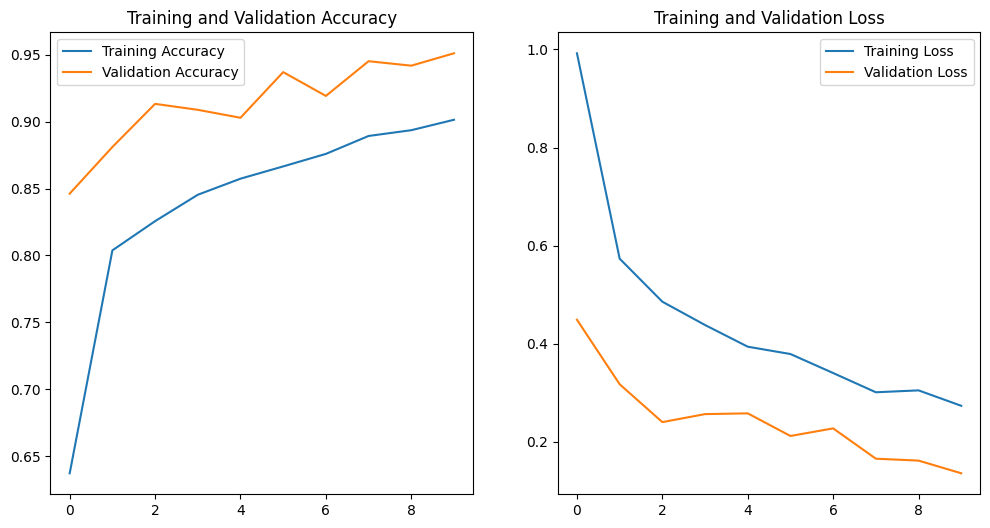

In [6]:
# Accuracy ar Loss-er graph dekha
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [7]:
# Ki ki class ache ar tader index koto
print(train_generator.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}
